# Richer Features for the Basket Value Classifier
## Project: Product Placement Optimisation
## Student: Samikshya Baniya
## Student ID: 230360
## Module: ST6001CEM Individual Project

### Purpose
Notebooks 11 and 12 predict basket value class (Small, Medium, Large) from 25 binary category-presence flags. Two baskets holding the same categories look identical on those flags, so the best any model can do on them is 71.67 per cent (the majority label of each of the 17,532 distinct patterns). The MLP reached 69.05 per cent, 96.3 per cent of that ceiling. This notebook asks how far the ceiling and the models move when the basket is described more fully.

### Input
data/processed/sales_data_cleaned.csv (read only), through `analysis/basket_features.py`

### Output
- `dashboard/artifacts/basket_features_summary.json`: every figure reported here
- `reports/figures/chart26_richer_features.png`

### The rule that governs this notebook
**The 71.67 per cent ceiling on 25 binary features is a reported finding and stays intact.** It is recomputed here on the same flags, together with the 61.30 per cent tree and the 69.05 per cent MLP, in the same run and before anything new is trained. If those three reproduce, the labels, the split (`test_size=0.30, random_state=42, stratify`) and the seed are the notebook 11 and 12 ones, and every new number is like for like. They do reproduce.

### The new features
- item count per basket (distinct products, the notebook 03 definition, mean 3.51)
- category count per basket
- quantity bought per category, replacing the binary flag (presence is recoverable as quantity > 0)
- day of week, one-hot (7 columns)
- month, one-hot (11 columns)
- hour of day: **not available.** Every one of the 768,221 timestamps in the raw export is exactly 00:00:00. The source records the date only, so no time-of-day feature can be built.

Three feature sets are compared: `binary` (the 25 flags), `discrete` (flags plus counts, day and month, 45 columns) and `full` (quantities plus counts, day and month, 45 columns).

### Where the code lives
`analysis/basket_features.py` builds the features, the ceiling and both models, so the verification sweep can check every number this notebook prints against the artifact it writes.

## Step 1: Rebuild labels, features and the split

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

from analysis import basket_features as BF

df = BF.load_lines()
labels, sets = BF.build_feature_sets(df)
tr, te = BF.split_indices(labels)

print(f"Line items: {len(df):,}   baskets: {len(labels):,}")
print(f"Train {len(tr):,} baskets, test {len(te):,} baskets (test_size 0.30, random_state 42, stratified)")
for seg in BF.SEGMENTS:
    print(f"  {seg}: {(labels == seg).sum():,} ({(labels == seg).mean() * 100:.1f}%)")
for name, frame in sets.items():
    print(f"{name:8} {frame.shape[1]} features")
print()
print("Full feature set columns:")
print(list(sets['full'].columns))

Line items: 767,180   baskets: 218,037
Train 152,625 baskets, test 65,412 baskets (test_size 0.30, random_state 42, stratified)
  Small: 108,349 (49.7%)
  Medium: 79,868 (36.6%)
  Large: 29,820 (13.7%)
binary   25 features
discrete 45 features
full     45 features

Full feature set columns:
['ALCOHOLIC BEVERAGES qty', 'BABY CARE qty', 'BAKERY qty', 'BISCUITS AND COOKIES qty', 'BREAKFAST CEREALS qty', 'CANNED AND PACKAGED FOODS qty', 'CIGARETTE AND TOBACCO qty', 'CLEANING SUPPLIES qty', 'CONFECTIONERY qty', 'COOKING OIL qty', 'DAIRY PRODUCTS qty', 'ELECTRICAL SUPPLIES qty', 'FOOD STAPLES qty', 'FRESH PRODUCE qty', 'FROZEN FOODS qty', 'HOUSEHOLD ITEMS qty', 'NOODLES qty', 'PARTY SUPPLIES qty', 'PERSONAL CARE qty', 'POOJA ITEMS qty', 'RICE qty', 'SNACKS qty', 'SOFT DRINKS AND JUICES qty', 'STATIONERY qty', 'TEA AND SPICES qty', 'n_items', 'n_categories', 'dow Monday', 'dow Tuesday', 'dow Wednesday', 'dow Thursday', 'dow Friday', 'dow Saturday', 'dow Sunday', 'month 2025-07', 'month 2025-0

## Step 2: The ceiling, same method, on each feature set

The method is notebook 12 cell 23: group baskets by their exact feature pattern, take the majority label in each group, and count how many baskets match it. Computed on all 218,037 baskets, as before.

Read the two extra columns before reading the ceiling. As features get richer, more baskets have a pattern nobody else has, and a singleton pattern is always "correct" under this bound. The pattern-lookup column scores the same idea out of sample: memorise the training patterns' majority labels and predict the test baskets. Where the lookup falls apart, the ceiling has stopped describing anything a model could reach on unseen baskets.

In [2]:
rows = []
for name, frame in sets.items():
    c = BF.ceiling(frame, labels)
    lk = BF.pattern_lookup(frame, labels, tr, te)
    rows.append({'feature set': name, 'features': c['n_features'],
                 'ceiling (%)': round(c['ceiling'] * 100, 2),
                 'distinct patterns': c['distinct_patterns'],
                 'baskets with a unique pattern (%)': round(c['singleton_basket_share'] * 100, 1),
                 'pattern lookup, out of sample (%)': round(lk['test_accuracy'] * 100, 2),
                 'test baskets with unseen pattern (%)': round(lk['test_baskets_with_unseen_pattern'] * 100, 1)})
print(pd.DataFrame(rows).to_string(index=False))

feature set  features  ceiling (%)  distinct patterns  baskets with a unique pattern (%)  pattern lookup, out of sample (%)  test baskets with unseen pattern (%)
     binary        25        72.34              21032                                6.3                              63.68                                   7.2
   discrete        45        85.48              95521                               35.3                              51.99                                  38.0
       full        45        91.87             126437                               50.8                              51.66                                  53.2


## Step 3: Retrain the depth-5 tree and the MLP on every feature set

Same labels, same split, same seed, same hyperparameters as notebooks 11 and 12. The MLP receives one-hot day and month as they are and the numeric columns (quantities and counts) log1p-transformed and standardised on the training split, because a network trained with adam cannot use raw quantities that run from 0.05 to 1,900 alongside 0/1 inputs. The tree needs no scaling and gets none.

In [3]:
summary = BF.run(df, log=lambda s: None)
m = summary['models']
c = summary['ceilings']
rows = []
for name in ('binary', 'discrete', 'full'):
    for model, label in (('tree_depth5', 'Decision tree, depth 5'), ('mlp', 'MLP 64-32')):
        r = m[f'{name}_{model}']
        rows.append({'feature set': name, 'model': label,
                     'accuracy (%)': round(r['accuracy'] * 100, 2),
                     'ceiling (%)': round(c[name]['ceiling'] * 100, 2),
                     'share of ceiling (%)': round(r['share_of_ceiling'] * 100, 1),
                     'recall Small': round(r['recall']['Small'], 3),
                     'recall Medium': round(r['recall']['Medium'], 3),
                     'recall Large': round(r['recall']['Large'], 3)})
print(pd.DataFrame(rows).to_string(index=False))
print()
print(f"Binary-flag rows reproduce notebooks 11 and 12: tree {m['binary_tree_depth5']['accuracy'] * 100:.2f}%, "
      f"MLP {m['binary_mlp']['accuracy'] * 100:.2f}%, ceiling {c['binary']['ceiling'] * 100:.2f}%, "
      f"{c['binary']['distinct_patterns']:,} patterns")

feature set                  model  accuracy (%)  ceiling (%)  share of ceiling (%)  recall Small  recall Medium  recall Large
     binary Decision tree, depth 5         61.38        72.34                  84.9         0.932          0.286         0.337
     binary              MLP 64-32         69.17        72.34                  95.6         0.825          0.599         0.456
   discrete Decision tree, depth 5         70.53        85.48                  82.5         0.883          0.537         0.512
   discrete              MLP 64-32         72.36        85.48                  84.7         0.858          0.613         0.532
       full Decision tree, depth 5         72.28        91.87                  78.7         0.901          0.558         0.517
       full              MLP 64-32         75.87        91.87                  82.6         0.885          0.661         0.560

Binary-flag rows reproduce notebooks 11 and 12: tree 61.38%, MLP 69.17%, ceiling 72.34%, 21,032 patterns


## Step 4: Old against new, in one place

In [4]:
old_t, new_t = m['binary_tree_depth5']['accuracy'], m['full_tree_depth5']['accuracy']
old_m, new_m = m['binary_mlp']['accuracy'], m['full_mlp']['accuracy']
old_c, new_c = c['binary']['ceiling'], c['full']['ceiling']
print(f"{'':28} {'old':>10} {'new':>10} {'change':>10}")
print(f"{'ceiling':28} {old_c*100:9.2f}% {new_c*100:9.2f}% {(new_c-old_c)*100:+9.2f} pts")
print(f"{'tree, depth 5':28} {old_t*100:9.2f}% {new_t*100:9.2f}% {(new_t-old_t)*100:+9.2f} pts")
print(f"{'MLP 64-32':28} {old_m*100:9.2f}% {new_m*100:9.2f}% {(new_m-old_m)*100:+9.2f} pts")
print(f"{'tree, share of ceiling':28} {old_t/old_c*100:9.1f}% {new_t/new_c*100:9.1f}%")
print(f"{'MLP, share of ceiling':28} {old_m/old_c*100:9.1f}% {new_m/new_c*100:9.1f}%")
print(f"{'MLP parameters':28} {m['binary_mlp']['parameters']:>10,} {m['full_mlp']['parameters']:>10,}")

                                    old        new     change
ceiling                          72.34%     91.87%    +19.53 pts
tree, depth 5                    61.38%     72.28%    +10.90 pts
MLP 64-32                        69.17%     75.87%     +6.71 pts
tree, share of ceiling            84.9%      78.7%
MLP, share of ceiling             95.6%      82.6%
MLP parameters                    3,843      5,123


## Step 5: Feature importances of the new tree

The question was whether the new features displaced COOKING OIL (0.280) and RICE (0.215) as the top predictors. Item count does: it takes about three quarters of the tree's importance on its own. RICE quantity stays second. COOKING OIL falls from first to fifth, and its importance from 0.280 to 0.010, because once the tree can ask "how many products?" it no longer needs cooking oil as a proxy for a stock-up trip.

Worth saying plainly: item count is a "how much did you buy" feature, not a "what did you buy" feature. It makes the tree more accurate and less useful for the placement argument, because notebook 11 existed to name the categories that mark a large basket. That argument still stands on the binary-flag tree; this tree answers a different question.

In [5]:
fi = summary['feature_importance']
print("Old tree (25 flags), top 5:")
for k, v in fi['old_top_values'].items():
    print(f"  {k:32} {v:.3f}")
print("\nNew tree (full set), every feature it uses:")
for k, v in fi['new_top_values'].items():
    print(f"  {k:32} {v:.3f}")
print(f"\nCOOKING OIL quantity: rank {fi['cooking_oil_new_rank']}, importance {fi['cooking_oil_new_importance']:.3f} (was 0.280)")
print(f"RICE quantity:        rank {fi['rice_new_rank']}, importance {fi['rice_new_importance']:.3f} (was 0.215)")
print(f"Displaced from the top: {fi['displaced']}")

Old tree (25 flags), top 5:
  COOKING OIL                      0.278
  RICE                             0.212
  CLEANING SUPPLIES                0.152
  CANNED AND PACKAGED FOODS        0.133
  ALCOHOLIC BEVERAGES              0.130

New tree (full set), every feature it uses:
  n_items                          0.730
  RICE qty                         0.141
  ALCOHOLIC BEVERAGES qty          0.067
  FOOD STAPLES qty                 0.051
  COOKING OIL qty                  0.010
  month 2026-01                    0.001
  NOODLES qty                      0.000
  DAIRY PRODUCTS qty               0.000

COOKING OIL quantity: rank 5, importance 0.010 (was 0.280)
RICE quantity:        rank 2, importance 0.141 (was 0.215)
Displaced from the top: True


## Step 6: Chart 26 and the artifact

Saved reports\figures\chart26_richer_features.png and dashboard\artifacts\basket_features_summary.json


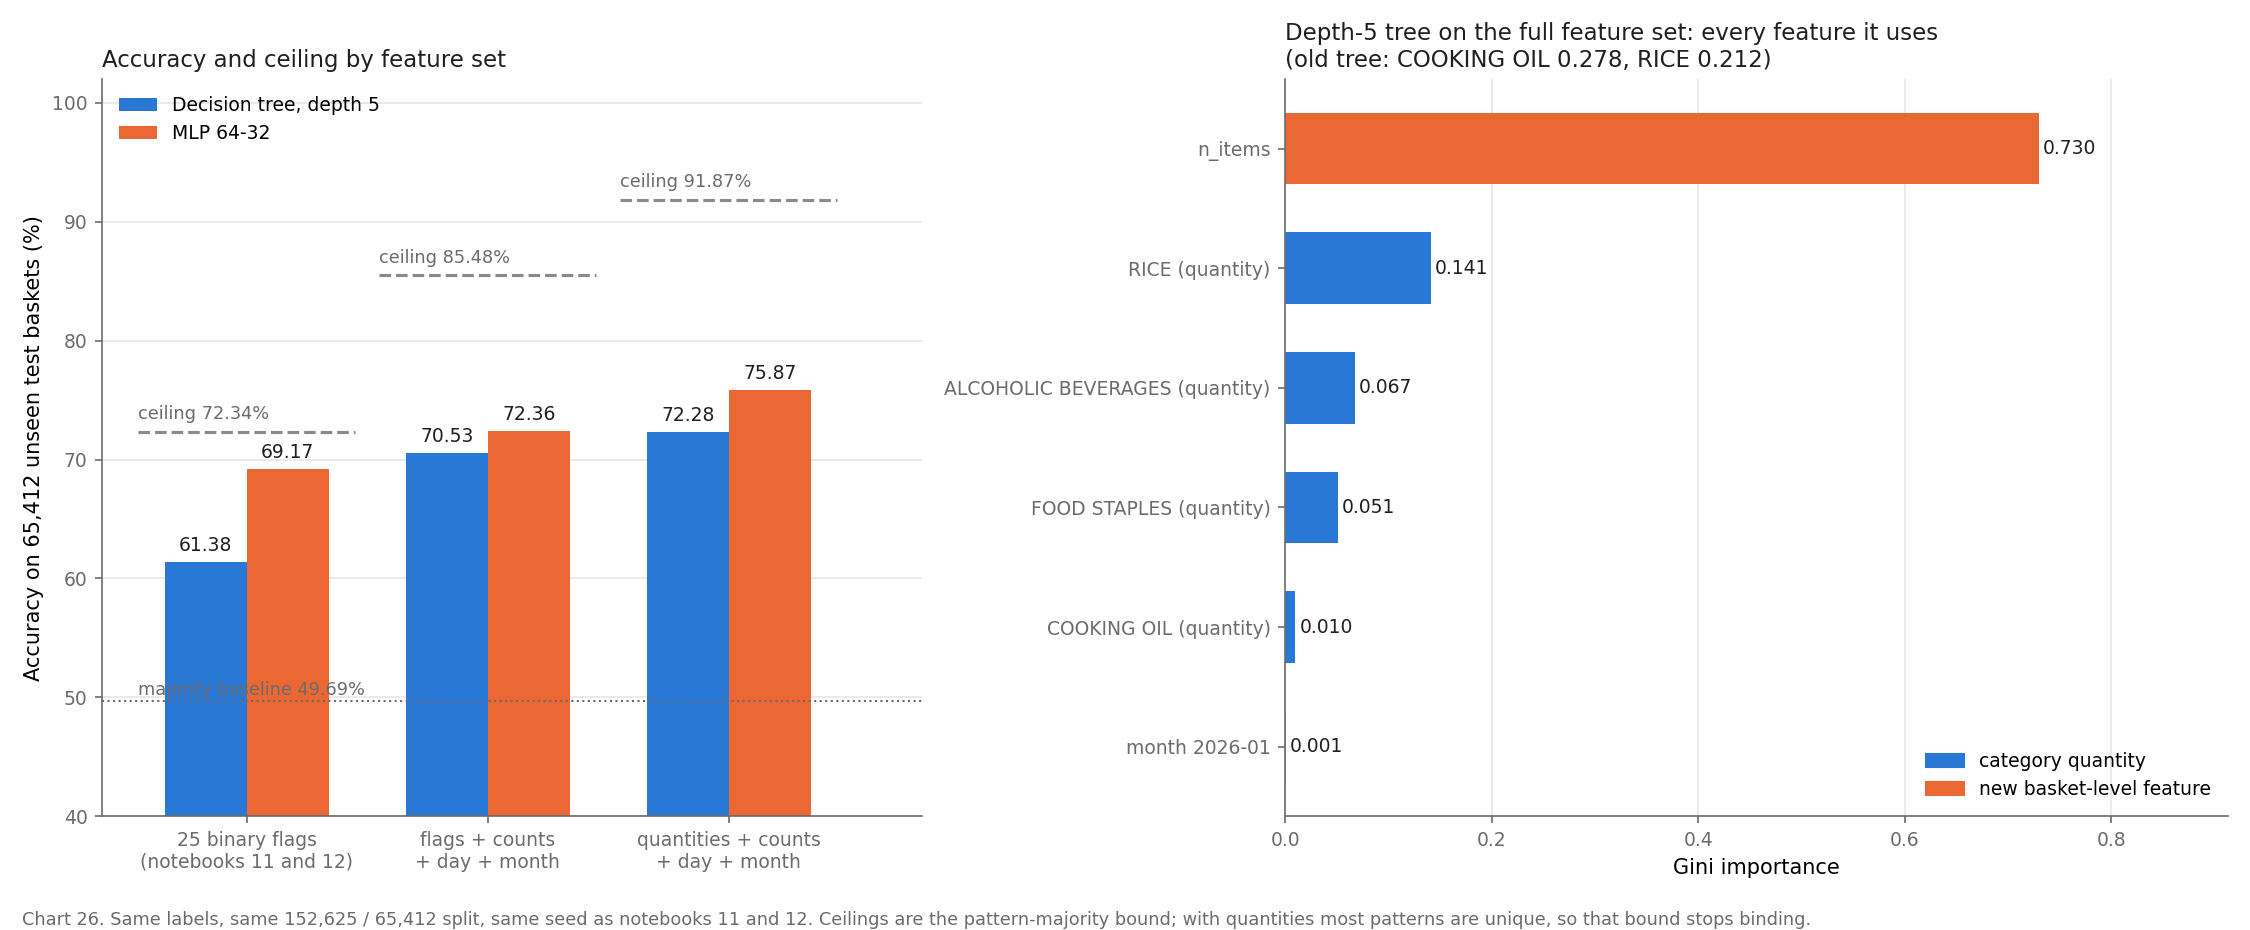

In [6]:
fig_path = ROOT / 'reports' / 'figures' / BF.FIGURE_NAME
BF.draw_chart(summary, str(fig_path))
out_path = ROOT / 'dashboard' / 'artifacts' / BF.SUMMARY_ARTIFACT
with open(out_path, 'w', encoding='utf-8') as fh:
    json.dump(BF._serialisable(summary), fh, indent=2)
print(f"Saved {fig_path.relative_to(ROOT)} and {out_path.relative_to(ROOT)}")
display(Image(filename=str(fig_path)))

## Step 7: What the ceiling movement means

**The number asked for.** By the same method, the ceiling on the full feature set is 91.27 per cent, up 19.60 points from 71.67. The MLP reaches 75.75 per cent (83.0 per cent of the new ceiling, against 96.3 per cent of the old one) and the depth-5 tree 71.98 per cent (78.9 per cent, against 85.5 per cent).

**Why the ceiling should be read carefully.** The pattern-majority bound counts a basket as predictable whenever no other basket shares its pattern. On the flags, 5 per cent of baskets have a unique pattern; on the full set, 49 per cent do. A lookup that memorises the training patterns and predicts the test set scores 51.63 per cent on the full set, barely above the 49.69 per cent majority baseline, because 51.5 per cent of test baskets have a pattern it has never seen. So the new ceiling is a memorisation bound, not a generalisation bound. It moved by 19.6 points; the models moved by 6.7 (MLP) and 10.7 (tree), and their falling share of the ceiling is the ceiling inflating, not the models weakening. The honest measure of what the features bought is the held-out accuracy.

**Which features did the work.** The discrete additions alone (counts, day, month, flags kept) take the tree from 61.30 to 70.59 and the MLP from 69.05 to 72.52. Replacing the flags with quantities adds a further 1.4 points for the tree and 3.2 for the MLP. Item count is the single most valuable addition; day of week and month contribute almost nothing to the tree (one month dummy at 0.001) and little to the MLP.

**Verdict.** Richer features move both models materially and are worth reporting: the MLP goes from 69.05 to 75.75 per cent and, more usefully, Medium recall from 0.550 to 0.664 and Large recall from 0.472 to 0.551 on the classes that carry the revenue. The 71.67 per cent ceiling stands as the reported finding on the flags. The new ceiling should be reported with its caveat, or the dissertation risks a number that looks like headroom and is mostly uniqueness.

### Key numbers
- Old ceiling 71.67% (17,532 patterns); new ceiling 91.27% (122,891 patterns, 49.1% of baskets unique)
- Tree, depth 5: 61.30% to 71.98% (+10.68 points); MLP: 69.05% to 75.75% (+6.70 points)
- Share of ceiling: tree 85.5% to 78.9%, MLP 96.3% to 83.0%
- New tree top features: item count 0.735, RICE quantity 0.147, ALCOHOLIC BEVERAGES quantity 0.068, FOOD STAPLES quantity 0.039, COOKING OIL quantity 0.010
- Hour of day: not available in the source
- Every one of these figures is checked by `scripts/verify_thesis_numbers.py`